# Local Mask R-CNN (torchvision) — PennFudan example (Windows / GitBash friendly)

This notebook:
- Downloads PennFudanPed dataset automatically
- Prepares a dataset & DataLoaders
- Builds torchvision's Mask R-CNN
- Runs a short training loop (demo)
- Runs inference & visualizes predictions

Adjust `DATA_DIR` below if you prefer a different local path.


In [2]:
# Imports & basic GPU check
import os, sys, time, zipfile, shutil
from pathlib import Path
import urllib.request
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import transforms as T

print("Python:", sys.version.splitlines()[0])
print("torch:", torch.__version__)
print("torch built with CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

# Device for model
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
torch: 2.8.0+cu128
torch built with CUDA: 12.8
CUDA available: True
Device: NVIDIA GeForce RTX 3060 Laptop GPU


In [ ]:
# Download PennFudanPed dataset (small demo dataset used by TorchVision tutorial)
# Source: http://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip
# 3

DATA_DIR = os.path.join(".", "data", "PennFudanPed")   # change if you want
os.makedirs(DATA_DIR, exist_ok=True)

zip_path = os.path.join(DATA_DIR, "PennFudanPed.zip")
if not os.path.isdir(os.path.join(DATA_DIR, "PennFudanPed")):
    if not os.path.exists(zip_path):
        print("Downloading PennFudanPed (around 20-30 MB)...")
        url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
        urllib.request.urlretrieve(url, zip_path)
        print("Download complete:", zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(DATA_DIR)
    print("Extracted to:", os.path.join(DATA_DIR, "PennFudanPed"))
else:
    print("PennFudanPed already present at", os.path.join(DATA_DIR, "PennFudanPed"))

# Define dataset dirs
ROOT = os.path.join(DATA_DIR, "PennFudanPed")
IMAGES_DIR = os.path.join(ROOT, "PNGImages")
MASKS_DIR  = os.path.join(ROOT, "PedMasks")

print("Images:", IMAGES_DIR)
print("Masks:", MASKS_DIR)
print("Example files:", sorted(os.listdir(IMAGES_DIR))[:5])


PennFudanPed already present at .\data\PennFudanPed\PennFudanPed
Images: .\data\PennFudanPed\PennFudanPed\PNGImages
Masks: .\data\PennFudanPed\PennFudanPed\PedMasks
Example files: ['FudanPed00001.png', 'FudanPed00002.png', 'FudanPed00003.png', 'FudanPed00004.png', 'FudanPed00005.png']


In [ ]:
# Transforms and collate_fn
# 4
def get_transform(train):
    transforms = []
    transforms.append(T.ToTensor())   # PIL image -> tensor
    # you can add augmentations for train (random flip etc.)
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    return T.Compose(transforms)

def collate_fn(batch):
    return tuple(zip(*batch))


In [ ]:
# Dataset Class
# PennFudanDataset adapted for torchvision Mask R-CNN
# 5 
import torch
from torch.utils.data import Dataset
import numpy as np
from PIL import Image
import os

class PennFudanDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transforms=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(images_dir)))
        self.masks = list(sorted(os.listdir(masks_dir)))

    def __getitem__(self, idx):
        # load images & masks
        img_path = os.path.join(self.images_dir, self.imgs[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)  # each object instance has a different color (value) in the mask image

        mask_np = np.array(mask)
        # instances are labeled with different integer values > 0
        obj_ids = np.unique(mask_np)
        obj_ids = obj_ids[obj_ids != 0]  # remove background id=0

        # masks: (num_instances, H, W)
        masks = mask_np == obj_ids[:, None, None]

        # boxes: compute bounding boxes from masks
        num_objs = len(obj_ids)
        boxes = []
        for i in range(num_objs):
            pos = np.where(masks[i])
            if pos[0].size == 0:
                # fallback: tiny object - create a small box
                boxes.append([0, 0, 1, 1])
            else:
                xmin = np.min(pos[1])
                xmax = np.max(pos[1])
                ymin = np.min(pos[0])
                ymax = np.max(pos[0])
                boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((num_objs,), dtype=torch.int64)  # all 1 (single class: person / cell)
        masks = torch.as_tensor(masks, dtype=torch.uint8)

        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.imgs)


In [ ]:
# model builer 
# 6

from torchvision.models.detection import maskrcnn_resnet50_fpn

def get_model_instance_segmentation(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = maskrcnn_resnet50_fpn(pretrained=True)
    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace box predictor with new one for our num_classes
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

    # now get number of input features for mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes)
    return model


In [9]:
# 7 
# prepare datasets and data loaders 
dataset = PennFudanDataset(IMAGES_DIR, MASKS_DIR, transforms=get_transform(train=True))
dataset_test = PennFudanDataset(IMAGES_DIR, MASKS_DIR, transforms=get_transform(train=False))

# split indices for train/test
indices = torch.randperm(len(dataset)).tolist()
split = int(0.8 * len(indices))
train_indices = indices[:split]
test_indices = indices[split:]

from torch.utils.data import Subset, DataLoader
train_dataset = Subset(dataset, train_indices)
test_dataset  = Subset(dataset_test, test_indices)

# DataLoaders (Windows-safe)
num_workers = 0
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=num_workers, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, num_workers=num_workers, collate_fn=collate_fn)

print("Train size:", len(train_dataset), "Test size:", len(test_dataset))


Train size: 136 Test size: 34


In [10]:
# Instantiate optimiser &  lr
num_classes = 2  # background + object (person / cell)
model = get_model_instance_segmentation(num_classes)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


In [11]:
# 9 
# simple train for 2 epochs 
# Simple training loop — just a sanity run (not optimized)
num_epochs = 2

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    t0 = time.time()
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()

    lr_scheduler.step()
    t1 = time.time()
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss:.4f} Time: {t1-t0:.1f}s")
    
# Save a checkpoint
ckpt_path = "maskrcnn_demo.pth"
torch.save(model.state_dict(), ckpt_path)
print("Saved model to", ckpt_path)


Epoch [1/2] Loss: 67.3699 Time: 32.2s
Epoch [2/2] Loss: 48.6568 Time: 25.4s
Saved model to maskrcnn_demo.pth


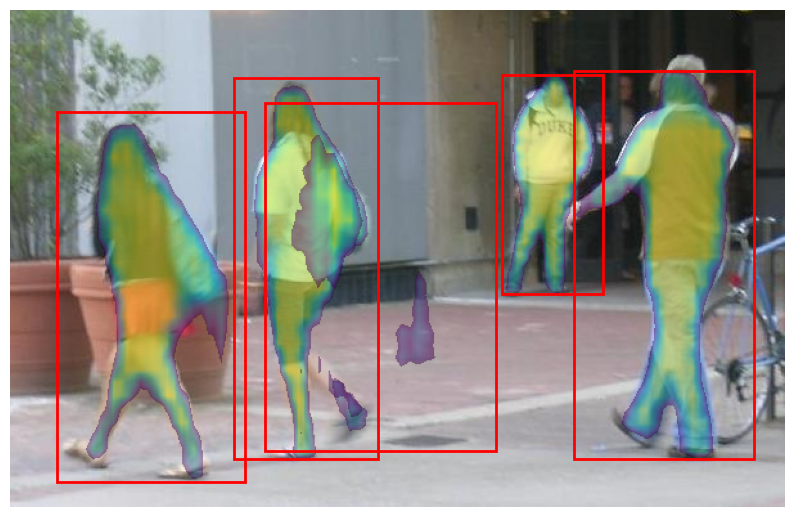

In [12]:
# 10
# Inference and visualization helper
model.eval()
import matplotlib.patches as patches

def show_image_with_results(img_tensor, outputs, score_thresh=0.5, figsize=(10,10)):
    img = img_tensor.mul(255).permute(1,2,0).byte().cpu().numpy()
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(img)
    if outputs is None:
        plt.show()
        return

    boxes = outputs.get('boxes')
    masks = outputs.get('masks')
    scores = outputs.get('scores')

    for i, score in enumerate(scores):
        if score < score_thresh:
            continue
        box = boxes[i].cpu().numpy().astype(int)
        ymin, xmin, ymax, xmax = box[1], box[0], box[3], box[2]
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        # overlay mask
        mask = masks[i, 0].cpu().numpy()
        ax.imshow(np.ma.masked_where(mask < 0.5, mask), alpha=0.5)
    plt.axis('off')
    plt.show()

# Run on a few images from test set
for imgs, targets in test_loader:
    imgs = [img.to(device) for img in imgs]
    with torch.no_grad():
        outputs = model(imgs)
    # outputs is a list — show first
    out0 = outputs[0]
    show_image_with_results(imgs[0].cpu(), out0, score_thresh=0.5)
    break
